In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 외부 폰트 쓰는 라이브러리

# 그래프를 그리기위한 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # 폰트설정
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 폰트설정
plt.rcParams['figure.figsize'] = 12,6 # 그래프의 크기
plt.rcParams['font.size'] = 14 # 글자 크기
plt.rcParams['axes.unicode_minus'] = False

### 선 그래프
- 데이터 프레임의 컬럼 하나가 선 하나가 된다.
- index가 x 축으로 설정된다.
- 전체값의 최대와 최소 범위가 y축의 범위로 설정된다
- 컬럼의 이름은 각 선의 이름이 되고 범례에 나타난다.

In [7]:
# 랜덤값 3개가 들어있는 행렬 100개를 생성한다.
x = np.random.randn(100,3)
# 2026년 1월 1일부터 100일치 날짜를 가져온다.
index = pd.date_range('2026-01-01', periods=100)

df1 = pd.DataFrame(x, index=index, columns=['A','B','C'])
df1

,A,B,C
2026-01-01,2.134993,-0.435314,-0.574394
2026-01-02,0.230890,1.055942,0.143773
2026-01-03,-0.570326,-0.197194,0.065390
2026-01-04,-0.812494,-0.237582,-1.488966
2026-01-05,0.907999,-0.256758,-0.014160
...,...,...,...
2026-04-06,2.091439,1.402486,-0.901176
2026-04-07,0.930636,0.321232,0.357476
2026-04-08,-1.072208,-0.104603,0.702932
2026-04-09,-0.435791,-1.099766,-1.093605


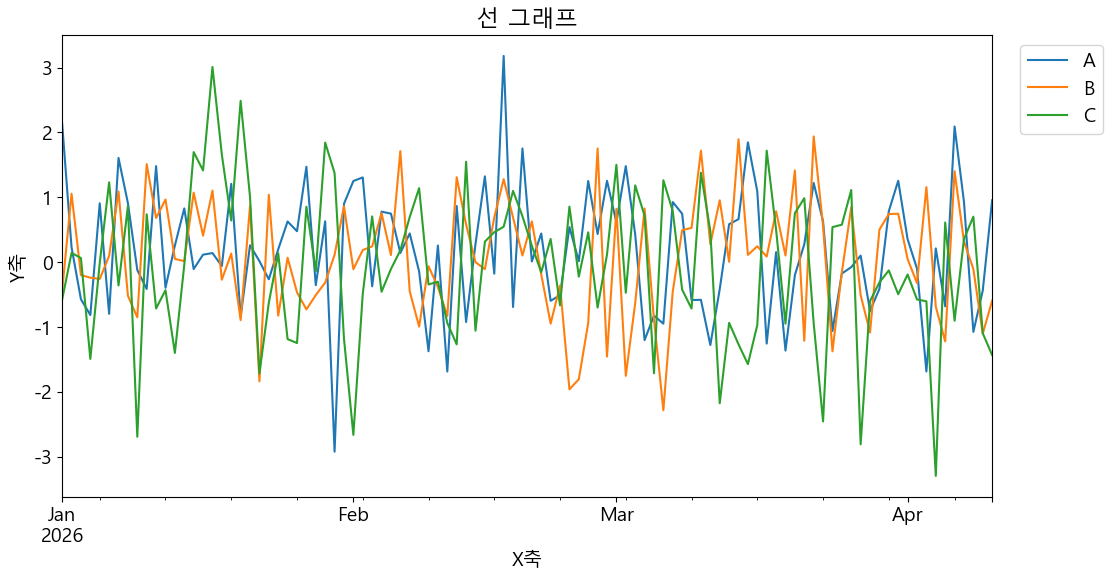

In [17]:
df1.plot()
plt.title('선 그래프')
plt.xlabel('X축')
plt.ylabel('Y축')
# 범례 위치 조정
plt.legend(bbox_to_anchor=(1.02,1))
plt.show()

### 막대 그래프

In [18]:
iris = pd.read_csv('data/iris.csv', encoding='euc-kr')
iris.columns=['꽃받침길이','꽃받침너비','꽃잎길이','꽃잎너비','품종']
iris

,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


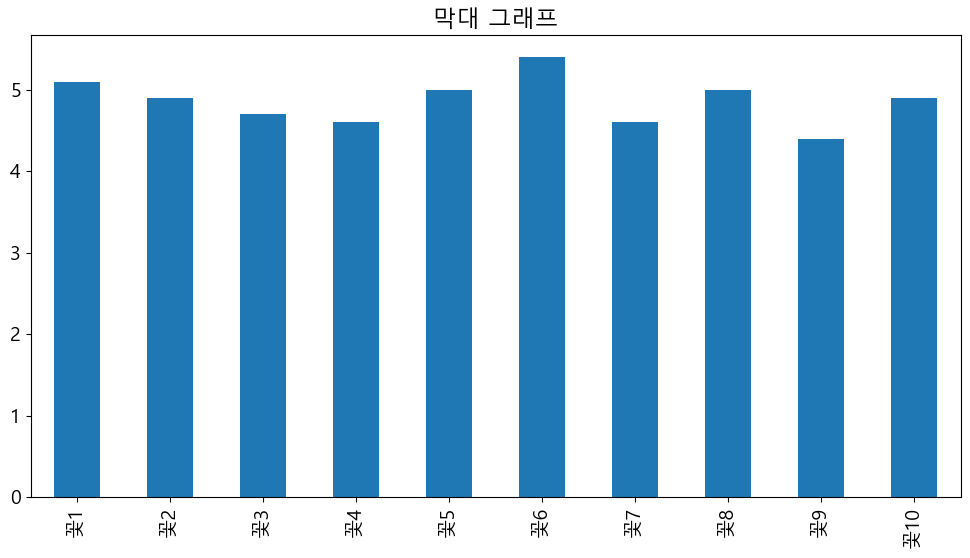

In [29]:
iris2 = iris.copy()

a1 = iris2['꽃받침길이'][:10]
a1.index = ['꽃1','꽃2','꽃3','꽃4','꽃5','꽃6','꽃7','꽃8','꽃9','꽃10']

# Series를 통해 막대 그래프를 그린다.
# plot 함수의 kind라는 매개변수에 그리고자 하는 그래프의 타입 문자열을 넣어주면 그래프를 그려준다.
# 각 값이 각각 막대 그래프로 표현되고
# index를 X축의 눈금으로 사용한다.
a1.plot(kind='bar')
plt.title('막대 그래프')
plt.show()

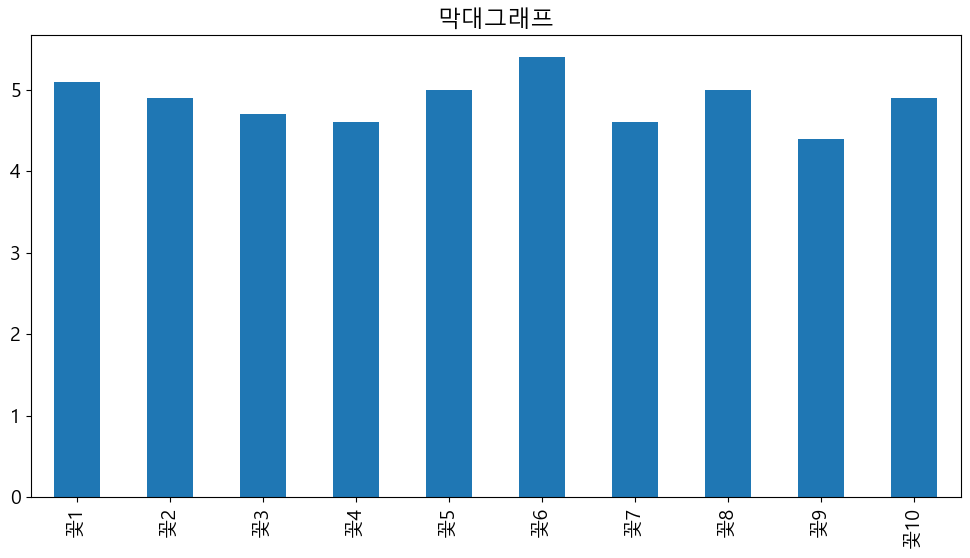

In [31]:
# 일부 함수들은 그래프를 그리는 함수를 따로 제공하기도 한다.
a1.plot.bar()
plt.title('막대그래프')
plt.show()

,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비
꽃1,5.1,3.5,1.4,0.2
꽃2,4.9,3.0,1.4,0.2
꽃3,4.7,3.2,1.3,0.2
꽃4,4.6,3.1,1.5,0.2
꽃5,5.0,3.6,1.4,0.2
꽃6,5.4,3.9,1.7,0.4
꽃7,4.6,3.4,1.4,0.3
꽃8,5.0,3.4,1.5,0.2
꽃9,4.4,2.9,1.4,0.2
꽃10,4.9,3.1,1.5,0.1


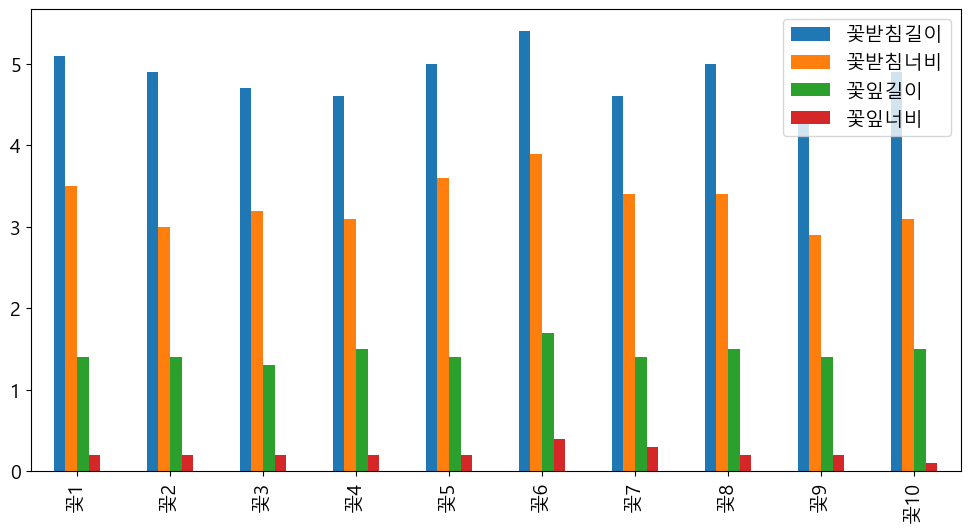

In [37]:
# 데이터 프레임(컬럼이 2개 이상)을 통해 막대 그래프를 그려본다.

df2 = iris.drop('품종', axis=1)
a1 = df2.head(10)
a1.index = ['꽃1','꽃2','꽃3','꽃4','꽃5','꽃6','꽃7','꽃8','꽃9','꽃10']
display(a1)

# 하나의 행을 추출하여 행 내의 컬럼별 막대 그래프를 그리고
# 그것들을 하나의 막대 그룹으로 묶어 준다.
# index가 x축의 눈금이 된다.
a1.plot(kind='bar')
plt.show()

### 파이그래프
- Series를 통해 그린다.
- 각 Series의 값을 통해 비율을 계산하여 파이 그래프를 그린다.
- 매개변수의 구성은 앞서 살펴보았던 matplotlib의 파이 그래프와 동일하다.

품종
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: >

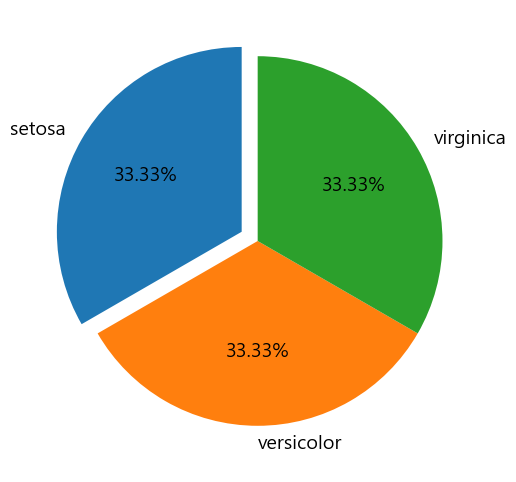

In [45]:
a1 = iris['품종'].value_counts()
display(a1)

a1.plot(kind='pie', autopct='%.2f%%',startangle=90, explode=[0.1,0,0])

### 히스토그램
- 주어진 데이터 프레임에서 숫자로 구성되어 있는 컬럼들을 모아 히스토그램을 그려준다.
- 다수의 컬럼을 가지고 그리면 겹치는 부분들이 생기기 때문에 보기가 어려워 진다.

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: 꽃받침길이, Length: 150, dtype: float64

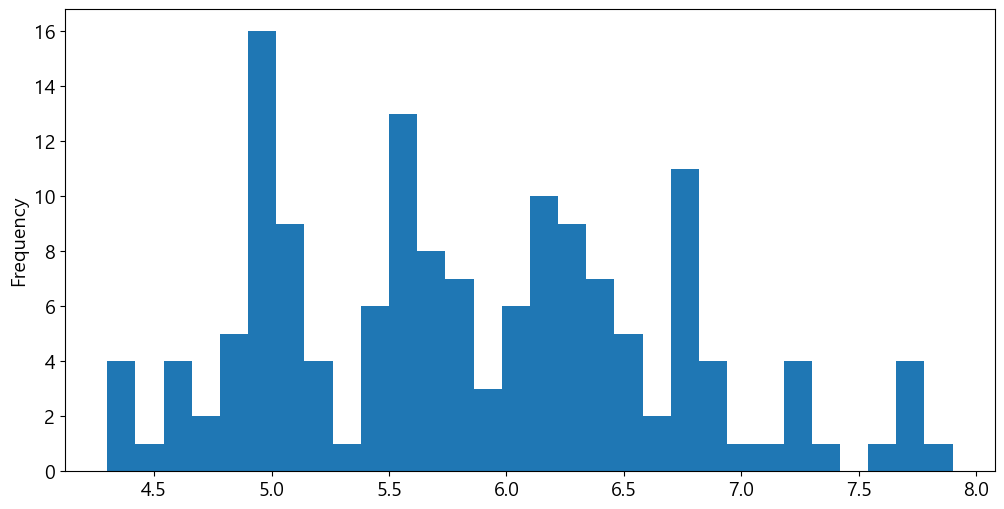

In [49]:
# bins : 구간의 개수
# Series를 통해 히스토그램을 그린다.
a1 = iris['꽃받침길이']
display(a1)

a1.plot(kind='hist', bins=30)
plt.show()

,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


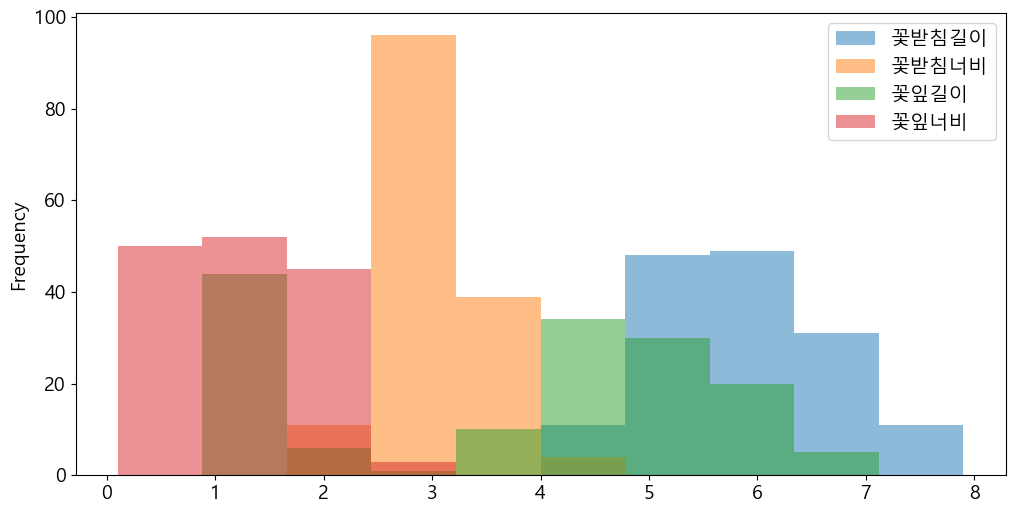

In [52]:
a1 = iris.drop('품종', axis=1)
display(a1)

a1.plot(kind='hist', alpha=0.5) #alpha : 투명도 설정
plt.show()

### KDE
- 다수의 히스토그램이 겹쳐져 있으면 보기가 힘들어진다.
- KDE를 사용하면 정확한 수치 비교는 되지 않지만 패턴을 비교해 볼 수 있다.
- 데이터의 밀도를 구해 밀도를 표현한 그래프

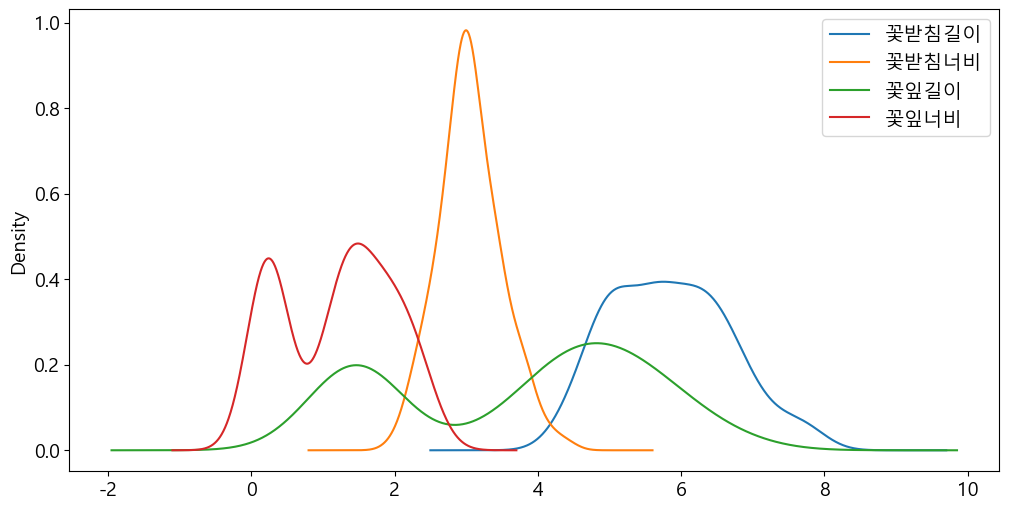

In [53]:
a1.plot(kind='kde')
plt.show()

### BoxPlot
- 값의 경계나 극단치 확인을 위해 사용한다.
- IQR 값을 통해 극단치 최대 경계와 최소 경계를 계산하여 그 범위를 벗어나는 값은 원으로 표시해준다.

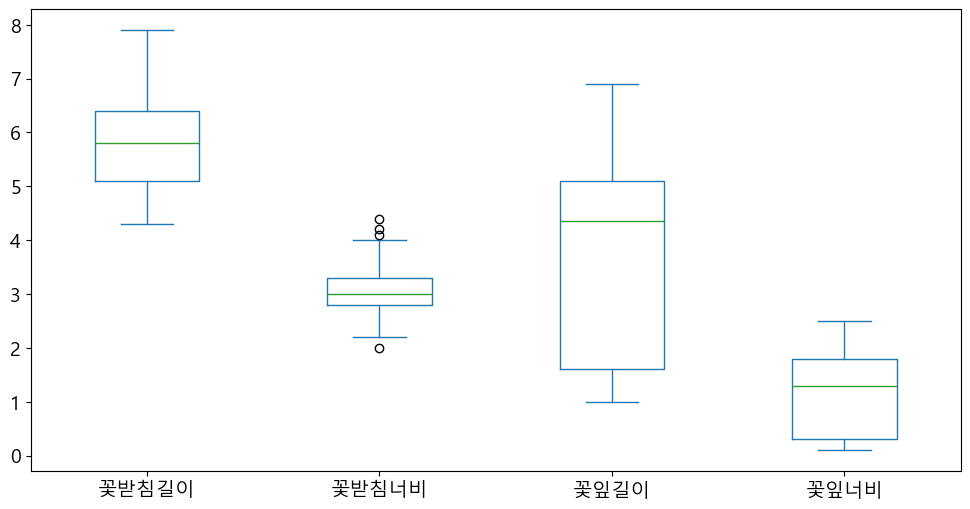

In [54]:
# BoxPlot은 범위형 데이터만 모아서 그려준다.
a1 = iris.drop('품종', axis=1)

a1.plot(kind='box')
plt.show()

In [60]:
# Q1(25%) 위치와 Q3(75%) 위치의 값
Q1 = iris['꽃받침너비'].quantile(q=0.25)
Q3 = iris['꽃받침너비'].quantile(q=0.75)

# IQR을 구한다
IQR = Q3 - Q1

# 극단치 최소경계
outliner_min = Q1 - (1.5 * IQR)
outliner_max = Q3 + (1.5 * IQR)

a1 = iris.query('꽃받침너비 < @outliner_min or 꽃받침너비 > @outliner_max')
a1

,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


### 산점도
- 산점도를 그릴 때는 x축에 사용할 컬럼의 이름과 y 축에 사용할 컬럼의 이름을 각각 넣어준다.

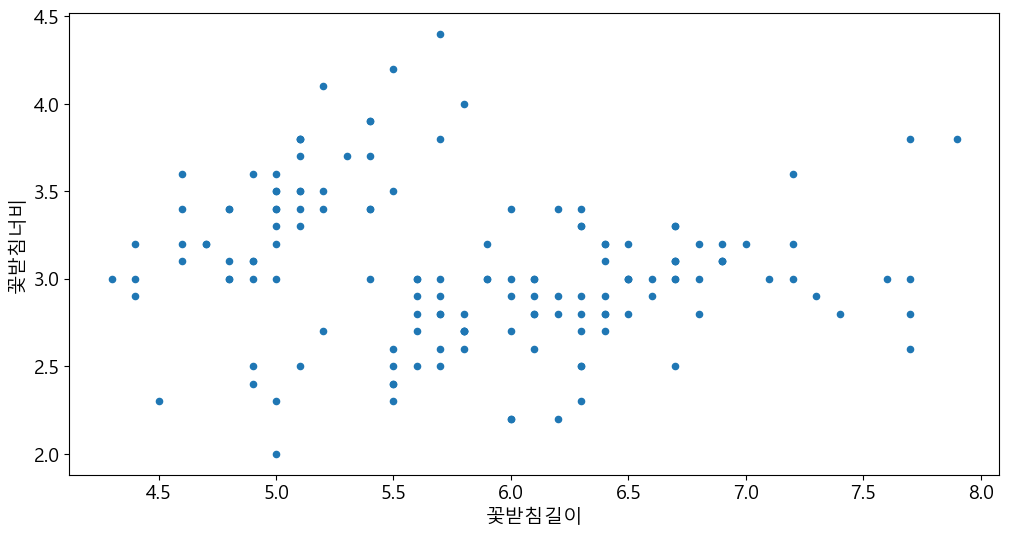

In [61]:
iris.plot(kind='scatter', x='꽃받침길이', y='꽃받침너비')
plt.show()

### 영역 그래프
- 선 그래프를 그릴 때 하단에 영역을 표시할 수 있다.

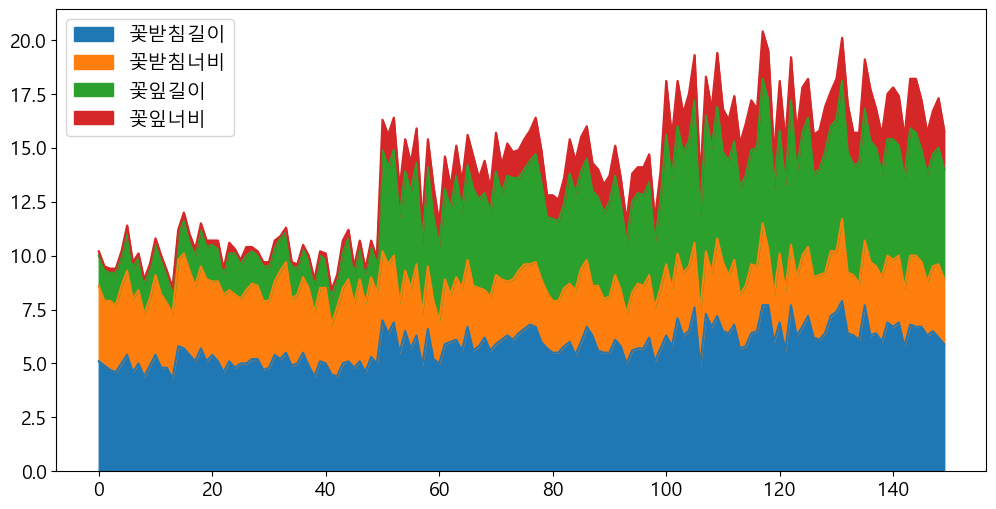

In [63]:
a1 = iris.drop('품종', axis=1)
a1.plot(kind='area')
plt.show()